# Problem Statement of the Project

The goal of this project is to classify Iris flowers into different species using their sepal and petal measurements.
By applying machine learning classification techniques, the model predicts the flower species based on given numerical features.
This project demonstrates the practical implementation of supervised learning and pattern recognition.

# Objective of the Project..

1. To understand and explore the Iris dataset using Exploratory Data Analysis (EDA)
2. To visualize the data using plots for better understanding
3. To build a classification model 
4. To classify Iris flowers into their respective species
5. To evaluate the model using appropriate performance metrics
6. To gain hands-on experience in supervised machine learning classification problems

# Importing Required Libraries..

In [16]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

In [17]:

df = pd.read_csv('IRIS.csv')
df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


In [18]:
df.head(3)

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa


In [19]:
df.tail(3)

,sepal_length,sepal_width,petal_length,petal_width,species
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica
149,5.9,3.0,5.1,1.8,Iris-virginica


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [21]:
df.shape


(150, 5)

In [22]:
print('Number of Rows', df.shape[0])
print('Number of Columns', df.shape[1])

Number of Rows 150
Number of Columns 5


# EDA

In [23]:
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [24]:
df.describe(exclude =['int64', 'float64'])

,species
count,150
unique,3
top,Iris-setosa
freq,50


# check missing values..

In [25]:
df.isnull().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

# Univariate Analysis

# sepal_length

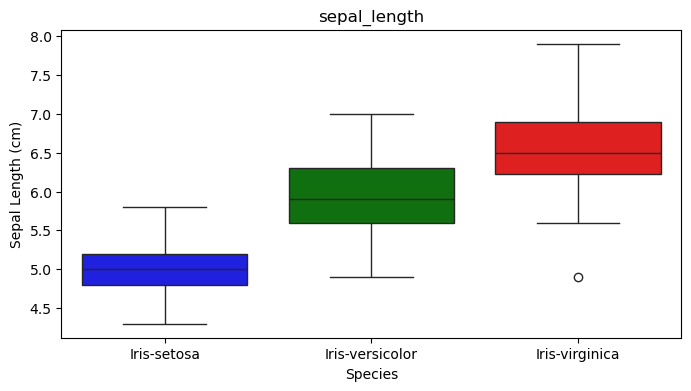

In [28]:
plt.figure(figsize=(8,4))
sns.set_style=('White')
# create a boxplot..
sns.boxplot(data=df, x='species', y='sepal_length',hue='species', palette=['blue','green','red'], legend =False)
plt.title('sepal_length')
plt.xlabel('Species')
plt.ylabel('Sepal Length (cm)')
plt.show()

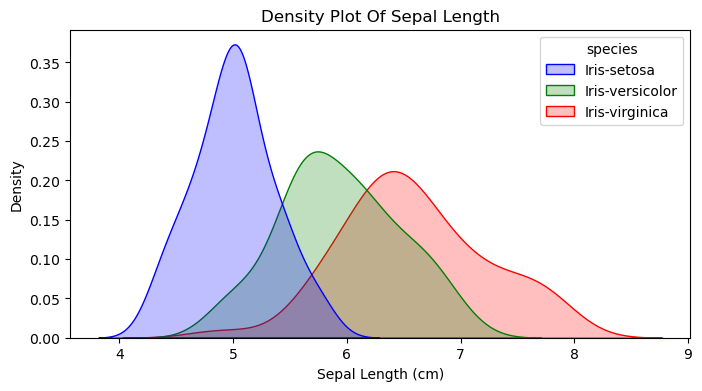

In [29]:
plt.figure(figsize=(8,4))
# density plot
sns.kdeplot(x ='sepal_length', data=df, hue='species', fill=True, palette=['blue','green','red'])
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Density')
plt.title('Density Plot Of Sepal Length')
plt.show()

# sepal_width

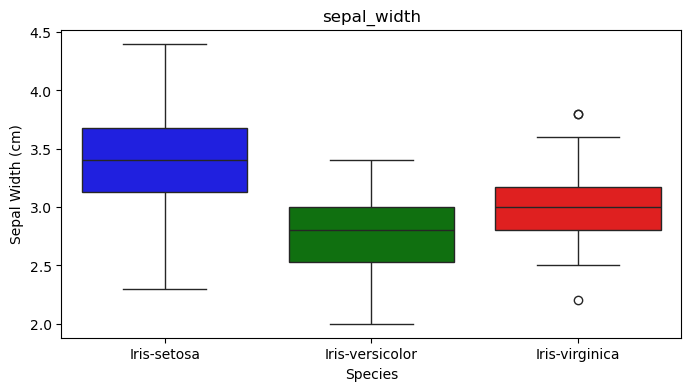

In [31]:
plt.figure(figsize=(8,4))
sns.set_style=('White')
# create a boxplot..
sns.boxplot(data=df, x='species', y='sepal_width',hue='species', palette=['blue','green','red'], legend =False)
plt.title('sepal_width')
plt.xlabel('Species')
plt.ylabel('Sepal Width (cm)')
plt.show()

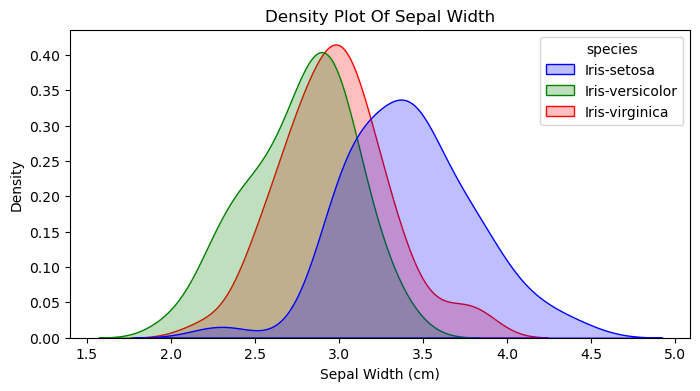

In [32]:
plt.figure(figsize=(8,4))
# density plot
sns.kdeplot(x ='sepal_width', data=df, hue='species', fill=True, palette=['blue','green','red'])
plt.xlabel('Sepal Width (cm)')
plt.ylabel('Density')
plt.title('Density Plot Of Sepal Width')
plt.show()

# petal_length

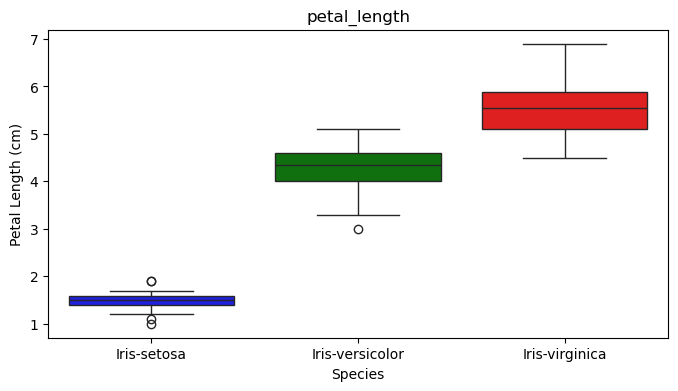

In [33]:
plt.figure(figsize=(8,4))
sns.set_style=('White')
# create a boxplot..
sns.boxplot(data=df, x='species', y='petal_length',hue='species', palette=['blue','green','red'], legend =False)
plt.title('petal_length')
plt.xlabel('Species')
plt.ylabel('Petal Length (cm)')
plt.show()

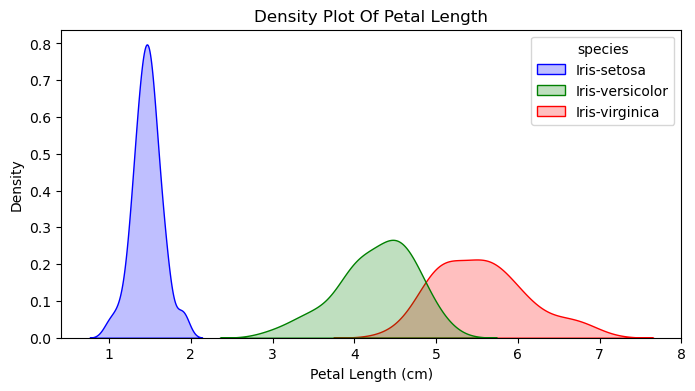

In [34]:
plt.figure(figsize=(8,4))
# density plot
sns.kdeplot(x ='petal_length', data=df, hue='species', fill=True, palette=['blue','green','red'])
plt.xlabel('Petal Length (cm)')
plt.ylabel('Density')
plt.title('Density Plot Of Petal Length')
plt.show()

# petal_width 

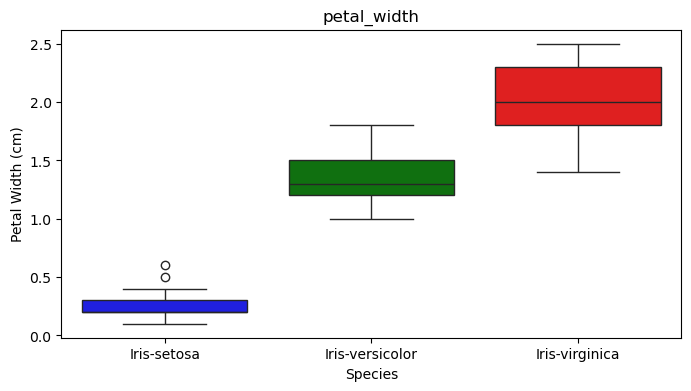

In [35]:
plt.figure(figsize=(8,4))
sns.set_style=('White')
# create a boxplot..
sns.boxplot(data=df, x='species', y='petal_width',hue='species', palette=['blue','green','red'], legend =False)
plt.title('petal_width')
plt.xlabel('Species')
plt.ylabel('Petal Width (cm)')
plt.show()

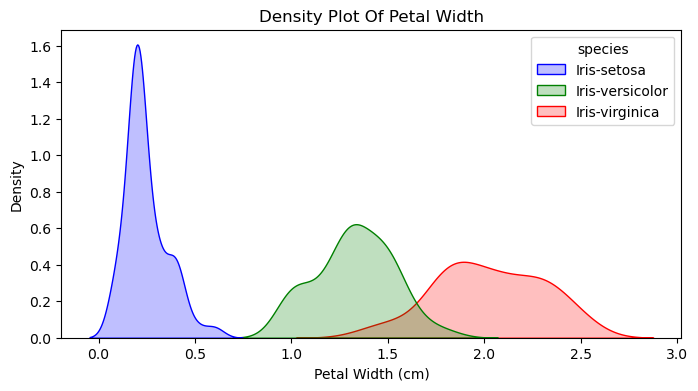

In [36]:
plt.figure(figsize=(8,4))
# density plot
sns.kdeplot(x ='petal_width', data=df, hue='species', fill=True, palette=['blue','green','red'])
plt.xlabel('Petal Width (cm)')
plt.ylabel('Density')
plt.title('Density Plot Of Petal Width')
plt.show()

# Frequency Distribution

In [37]:
df.columns

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')

In [38]:
df.groupby('species').size()

species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
dtype: int64

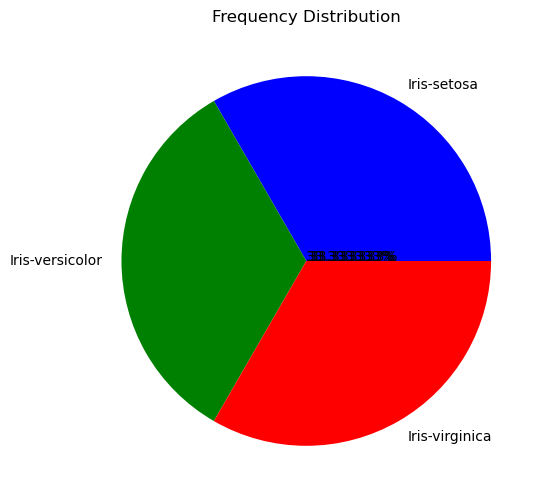

In [39]:
plt.figure(figsize=(8,6))
species_colors =['blue', 'green', 'red']
plt.pie(df['species'].value_counts(),labels=df['species'].unique(),colors=species_colors)
# add custom annotations to each slice
total_count = len(df)
for i, species in enumerate(df['species'].unique()):
    count = df['species'].value_counts()[species]
    percentage = (count/total_count)*100
    plt.annotate(f'{percentage:1f}%',(0,0),(1.3*i,0), textcoords='offset points')
plt.title('Frequency Distribution')
plt.show()

# Bivariate Analysis

sepal_length vs. sepal_width

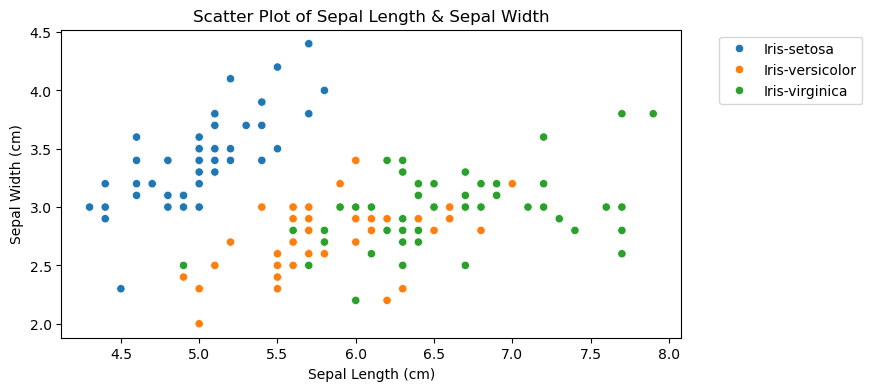

In [40]:
plt.figure(figsize=(8,4))
sns.set_style=('white')
sns.scatterplot(data=df, x='sepal_length', y='sepal_width', hue='species')
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')
plt.title('Scatter Plot of Sepal Length & Sepal Width')

# move the legend outside the graph
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

petal_length vs. petal_width

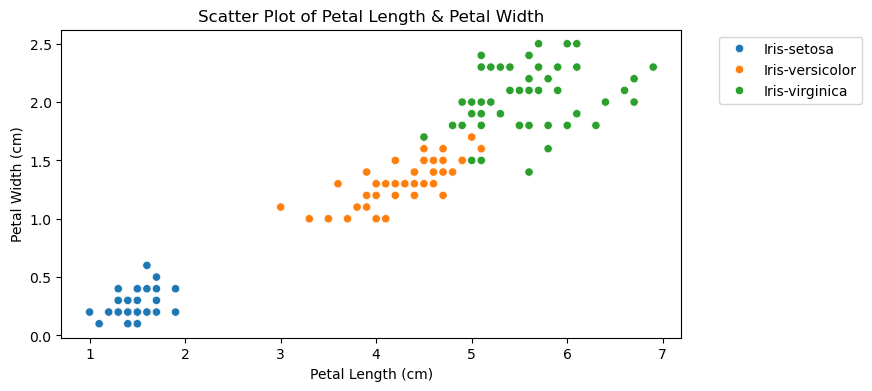

In [41]:
plt.figure(figsize=(8,4))
sns.set_style=('white')
sns.scatterplot(data=df, x='petal_length', y='petal_width', hue='species')
plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.title('Scatter Plot of Petal Length & Petal Width')

# move the legend outside the graph
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# splitting datasetinto features and targets

In [42]:
df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


In [43]:
x = df.drop(['species'], axis =1)
y=df['species']

# Scalling numerical columns

In [46]:
# scalling only the area column
scale= StandardScaler()
x_scaled = scale.fit_transform(x)
x_scaled = pd.DataFrame(columns= x.columns, data = x_scaled)
x_scaled.head()

,sepal_length,sepal_width,petal_length,petal_width
0,-0.900681,1.032057,-1.341272,-1.312977
1,-1.143017,-0.124958,-1.341272,-1.312977
2,-1.385353,0.337848,-1.398138,-1.312977
3,-1.506521,0.106445,-1.284407,-1.312977
4,-1.021849,1.263460,-1.341272,-1.312977


# Encoding categorical columns (i.e the target)

In [47]:
y= y.map({'Iris-setosa' :0,'Iris-versicolor':1,'Iris-virginica':2})
y

0      0
1      0
2      0
3      0
4      0
      ..
145    2
146    2
147    2
148    2
149    2
Name: species, Length: 150, dtype: int64

In [49]:
# from sklearn.model_selection import train_test_split
# split the dataset into training and testing sets
x_train, x_test, y_train, y_test= train_test_split(x_scaled,y,test_size=0.2, random_state=42)

In [50]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(120, 4)
(30, 4)
(120,)
(30,)


# Model Building and Evaluation

# decision tree

In [51]:
# Initialize and train the model
dt = DecisionTreeClassifier(random_state=42)
dt.fit(x_train, y_train)

# Make predictions on the best set
y_pred = dt.predict(x_test)
# evaluate on test set
accuracy = accuracy_score(y_test,y_pred)
precision= precision_score(y_test,y_pred,average='weighted')
recall = recall_score(y_test,y_pred,average='weighted')
print ('Decision Tree Classifier: ')
print('Accuracy: ', round(accuracy,4))
print('Precision: ', round(precision,4))
print('Recall: ', round(recall,4))
print ('Confusion Matrix : ')
print (confusion_matrix(y_test, y_pred))

Decision Tree Classifier: 
Accuracy:  1.0
Precision:  1.0
Recall:  1.0
Confusion Matrix : 
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


In [52]:
y_test.value_counts()

species
2    11
0    10
1     9
Name: count, dtype: int64

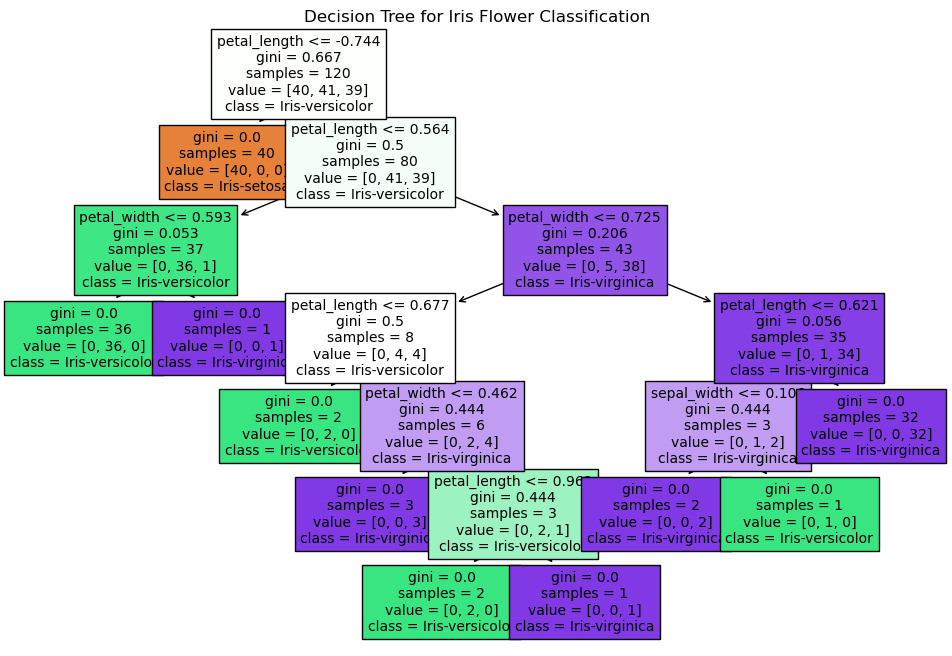

In [55]:
from sklearn import tree
# plot the decision tree
plt.figure(figsize=(12,8))
tree.plot_tree(dt,feature_names=x.columns, class_names= df.species.unique(),filled=True, fontsize=10)
plt.title('Decision Tree for Iris Flower Classification')
plt.show()